# Out-Ear EEG QC Review
Reads the CSVs from `data/qc/` produced by the `analysis/eeg_*` scripts and plots them for a first look at data quality across participants, channels, and tasks.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

QC = Path("../data/qc")
CHANNELS = [f"ch{i}" for i in range(1, 9)]
plt.rcParams["figure.facecolor"] = "white"


## (a) Waveform scale -- filtered ptp/rms at multiple timescales, per participant

In [2]:
wf_summary = pd.read_csv(QC / "eeg_waveform_scale_summary.csv")
wf_summary.head()


,pid,channel,window_s,n_windows,ptp_uv_median,ptp_uv_p95,rms_uv_median,rms_uv_p95,frac_abnormal_ptp,frac_abnormal_clip,frac_abnormal_any
0,P001,ch1,1.0,3442,372.823864,8056.504217,84.619509,2086.957949,0.334980,0.167054,0.492737
1,P001,ch1,2.0,1721,425.253120,13097.903983,91.431468,2451.840523,0.417199,0.168507,0.572342
2,P001,ch1,5.0,688,570.460218,22239.149879,103.026032,3095.171980,0.539244,0.174419,0.688953
3,P001,ch1,10.0,344,1048.892118,33161.429845,118.271961,3162.554827,0.639535,0.186047,0.781977
4,P001,ch2,1.0,3442,69.218666,766.705714,14.875407,171.478158,0.079605,0.201627,0.269611


*Per-participant x channel x window-size summary from `eeg_waveform_scale.py` -- median/p95 ptp+rms and the fraction of windows flagged abnormal, no cohort rollup yet.*

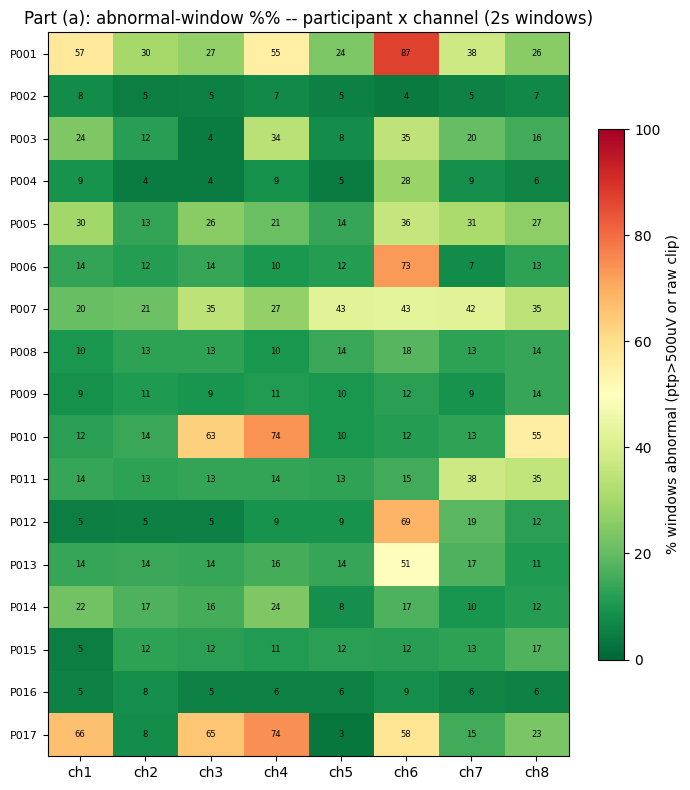

Shows which participant x channel combos spend the most 2s windows above the 500uV artifact threshold or with a raw ADC clip -- greener/lower is cleaner; look for whole rows (bad participant) vs. whole columns (bad channel).


In [3]:
# Heatmap: participant x channel, fraction of windows flagged abnormal (2s windows)
w2 = wf_summary[wf_summary.window_s == 2.0]
pivot = w2.pivot(index="pid", columns="channel", values="frac_abnormal_any")[CHANNELS]
fig, ax = plt.subplots(figsize=(7, 8))
im = ax.imshow(pivot.to_numpy() * 100, cmap="RdYlGn_r", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(8)); ax.set_xticklabels(CHANNELS)
ax.set_yticks(range(len(pivot))); ax.set_yticklabels(pivot.index, fontsize=8)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.iloc[i,j]*100:.0f}", ha="center", va="center", fontsize=6)
fig.colorbar(im, ax=ax, label="% windows abnormal (ptp>500uV or raw clip)", fraction=0.046)
ax.set_title("Part (a): abnormal-window %% -- participant x channel (2s windows)")
fig.tight_layout()
plt.show()
print("Shows which participant x channel combos spend the most 2s windows above the 500uV artifact threshold or with a raw ADC clip -- greener/lower is cleaner; look for whole rows (bad participant) vs. whole columns (bad channel).")


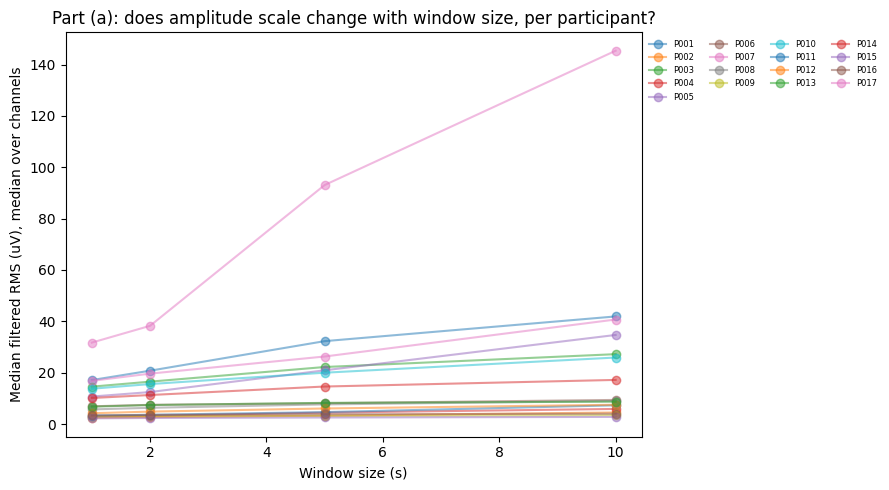

One line per participant, tracking their median filtered RMS as the window size grows from 1s to 10s -- a flat line means amplitude is stable across timescales; a rising/falling line means short bursts vs. sustained drift dominate that participant's signal.


In [4]:
# Median filtered RMS by channel, one line per participant, across window sizes
fig, ax = plt.subplots(figsize=(9, 5))
for pid, g in wf_summary.groupby("pid"):
    med_by_ws = g.groupby("window_s")["rms_uv_median"].median()
    ax.plot(med_by_ws.index, med_by_ws.values, marker="o", alpha=0.5, label=pid)
ax.set_xlabel("Window size (s)"); ax.set_ylabel("Median filtered RMS (uV), median over channels")
ax.set_title("Part (a): does amplitude scale change with window size, per participant?")
ax.legend(fontsize=6, ncol=4, frameon=False, loc="upper left", bbox_to_anchor=(1, 1))
fig.tight_layout()
plt.show()
print("One line per participant, tracking their median filtered RMS as the window size grows from 1s to 10s -- a flat line means amplitude is stable across timescales; a rising/falling line means short bursts vs. sustained drift dominate that participant's signal.")


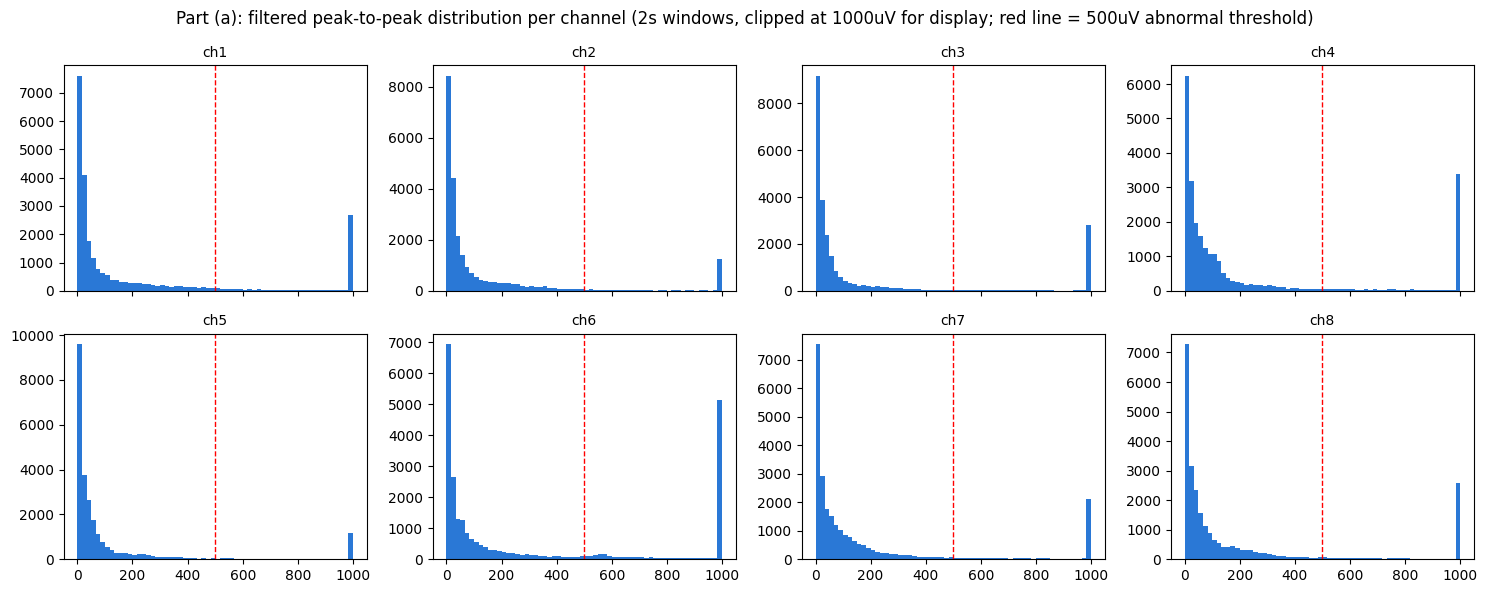

One histogram per channel, pooled across all participants and windows -- shows the overall shape of the ptp distribution and how much mass sits past the 500uV artifact line (red) rather than in the physiological ~10-100uV range.


In [5]:
# Per-channel distribution of ptp (2s windows) across ALL participants -- one panel per channel
windows = pd.read_csv(QC / "eeg_waveform_scale_windows.csv")
w2_full = windows[windows.window_s == 2.0]
fig, axes = plt.subplots(2, 4, figsize=(15, 6), sharex=True)
for ax, ch in zip(axes.ravel(), CHANNELS):
    vals = w2_full.loc[w2_full.channel == ch, "ptp_uv"]
    ax.hist(np.clip(vals, 0, 1000), bins=60, color="#2a78d6")
    ax.axvline(500, color="red", linestyle="--", linewidth=1)
    ax.set_title(ch, fontsize=10)
fig.suptitle("Part (a): filtered peak-to-peak distribution per channel (2s windows, clipped at 1000uV for display; red line = 500uV abnormal threshold)")
fig.tight_layout()
plt.show()
print("One histogram per channel, pooled across all participants and windows -- shows the overall shape of the ptp distribution and how much mass sits past the 500uV artifact line (red) rather than in the physiological ~10-100uV range.")


## (b) SNR factor impact and quality-by-task

In [6]:
snr_by_task = pd.read_csv(QC / "eeg_snr_by_task.csv")
reg = pd.read_csv(QC / "eeg_snr_factor_regression.csv")
snr_by_task.head()


,pid,channel,task,n_windows,snr_db_median,snr_db_p10,snr_db_p90,drift_ratio_db_median,hf_ratio_db_median,line_noise_60_db_median,headroom_fraction_median
0,P001,ch1,attention_focus_schulte,23,-3.398200,-14.062481,0.096341,2.942506,-10.157442,34.752022,0.594623
1,P001,ch1,attention_focus_stroop,24,-7.732986,-14.847715,0.123637,3.264606,-8.848902,32.720466,0.601053
2,P001,ch1,attention_highway,23,-7.683736,-16.066487,1.026124,4.701119,-1.626483,38.930917,0.494272
3,P001,ch1,emotion,125,-7.340954,-19.924438,-0.683152,13.212630,-19.945119,32.996774,0.369123
4,P001,ch1,preparation,5,-38.838858,-41.731356,-12.321259,8.953536,-31.956836,25.933293,0.155679


*Per-participant x channel x task SNR + factor medians from `eeg_snr_factors.py`, and the pooled correlation/regression table.*

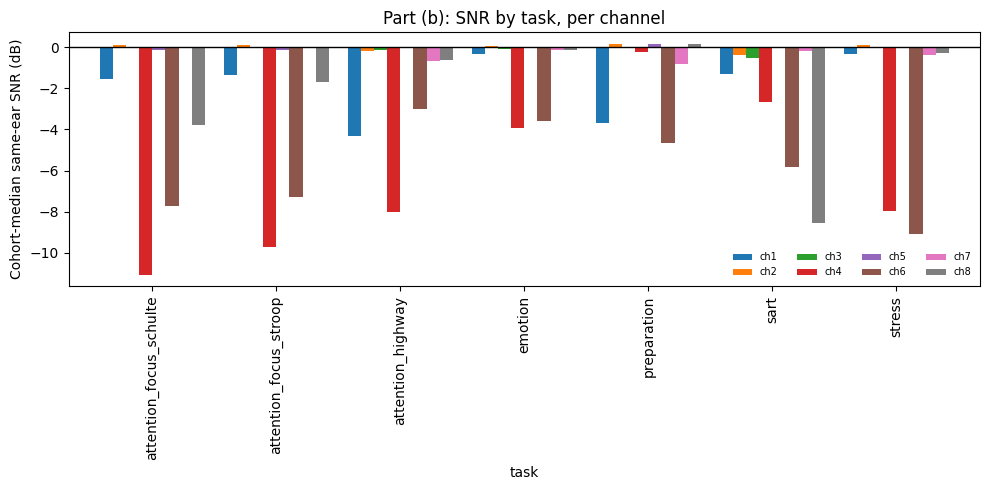

Cohort-median same-ear spatial SNR per channel, grouped by task -- flags whether a task (e.g. more movement in Stroop/highway) systematically drags SNR down, which matters because that could get learned as an artifact signature instead of a real task/label effect.


In [7]:
# SNR by task, per channel (cohort median across participants)
piv = snr_by_task.groupby(["task", "channel"])["snr_db_median"].median().unstack()[CHANNELS]
fig, ax = plt.subplots(figsize=(10, 5))
piv.plot(kind="bar", ax=ax, width=0.85)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Cohort-median same-ear SNR (dB)")
ax.set_title("Part (b): SNR by task, per channel")
ax.legend(fontsize=7, ncol=4, frameon=False)
fig.tight_layout()
plt.show()
print("Cohort-median same-ear spatial SNR per channel, grouped by task -- flags whether a task (e.g. more movement in Stroop/highway) systematically drags SNR down, which matters because that could get learned as an artifact signature instead of a real task/label effect.")


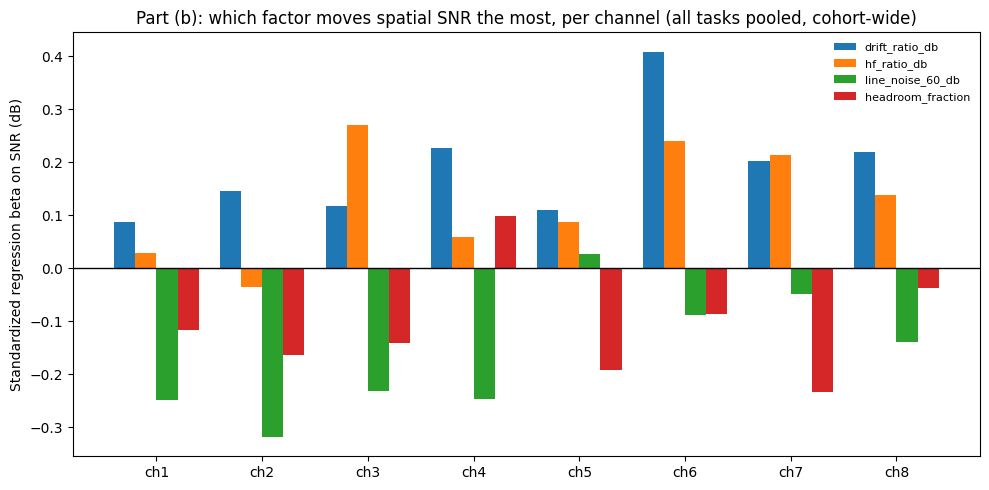

Standardized regression beta of each contamination factor (drift, HF/EMG, 60Hz line noise, low headroom) on same-ear SNR, per channel, all tasks pooled -- the tallest bar (either direction) is the factor most strongly associated with that channel's SNR swings; sign shows direction (e.g. negative line-noise beta = more line noise, lower SNR).


In [15]:
# Which factor best predicts SNR, per channel (cohort-pooled standardized regression beta)
cohort = reg[reg.scope == "cohort_pooled_channel"].set_index("channel").reindex(CHANNELS)
beta_cols = [c for c in cohort.columns if c.startswith("beta_")]
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(CHANNELS)); width = 0.8 / len(beta_cols)
for i, col in enumerate(beta_cols):
    ax.bar(x + i * width - 0.4 + width / 2, cohort[col], width=width, label=col.replace("beta_", ""))
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(CHANNELS)
ax.set_ylabel("Standardized regression beta on SNR (dB)")
ax.set_title("Part (b): which factor moves spatial SNR the most, per channel (all tasks pooled, cohort-wide)")
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()
plt.show()
print("Standardized regression beta of each contamination factor (drift, HF/EMG, 60Hz line noise, low headroom) on same-ear SNR, per channel, all tasks pooled -- the tallest bar (either direction) is the factor most strongly associated with that channel's SNR swings; sign shows direction (e.g. negative line-noise beta = more line noise, lower SNR).")


*Same regression as the bar chart above, in table form -- `r2` shows how much of that channel's SNR variance the four factors jointly explain (low r2 means something else not in this list is driving SNR).*

In [9]:
cohort[beta_cols + ["r2", "n_windows"]].round(3)


,beta_drift_ratio_db,beta_hf_ratio_db,beta_line_noise_60_db,beta_headroom_fraction,r2,n_windows
channel,,,,,,
ch1,0.087,0.029,-0.248,-0.117,0.098,3636
ch2,0.146,-0.036,-0.319,-0.165,0.190,3624
ch3,0.117,0.270,-0.231,-0.141,0.191,3575
ch4,0.227,0.060,-0.248,0.098,0.113,3553
ch5,0.111,0.088,0.027,-0.192,0.074,3608
ch6,0.409,0.240,-0.088,-0.086,0.158,3602
ch7,0.203,0.214,-0.048,-0.235,0.132,3603
ch8,0.219,0.139,-0.140,-0.038,0.089,3619


## (c) 1/f aperiodic exponent and spatial correlation, all windows vs. artifact-clean only

In [10]:
aperiodic = pd.read_csv(QC / "eeg_aperiodic_fit.csv")
corr_mat = pd.read_csv(QC / "eeg_channel_correlation_matrix.csv")
aperiodic.head()


,pid,channel,scope,n_windows,aperiodic_exponent_median,aperiodic_exponent_p25,aperiodic_exponent_p75,fit_r2_median
0,P001,ch1,all_windows,334,1.656725,0.409950,2.932046,0.650883
1,P001,ch2,all_windows,327,1.575076,0.951276,2.179048,0.711882
2,P001,ch3,all_windows,326,1.826339,1.158071,2.722161,0.765488
3,P001,ch4,all_windows,331,2.575461,1.514989,3.569057,0.851278
4,P001,ch5,all_windows,329,1.811703,1.103491,2.729111,0.747252


*Per-participant x channel aperiodic-fit summary, and the full pairwise correlation table, both from `eeg_spectral_morphology.py`, each with an `all_windows` vs. `clean_windows_only` scope.*

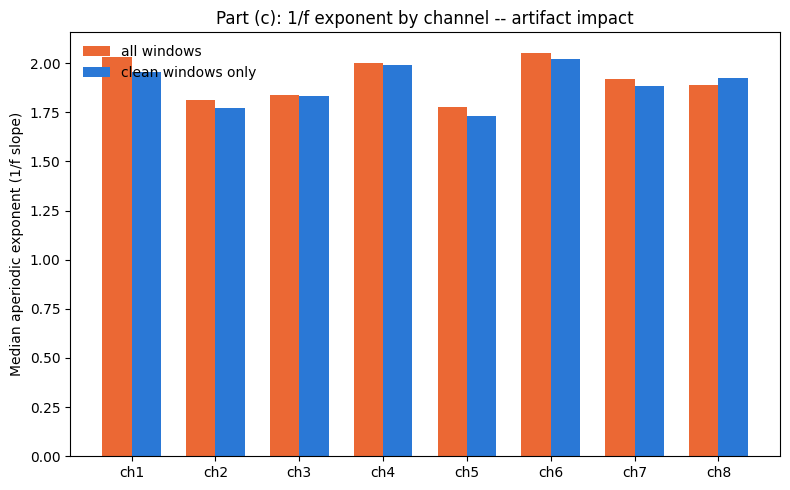

Median aperiodic (1/f) exponent per channel -- orange (all windows) vs. blue (artifact-clean only). Real EEG typically falls ~1-3; values here are compared across channels/scopes, not against a hard literature cutoff. A big orange-vs-blue gap means artifacts are distorting that channel's spectral shape, not just its amplitude.


In [11]:
# Aperiodic exponent per channel, all windows vs. clean-only (cohort median)
piv = aperiodic.groupby(["channel", "scope"])["aperiodic_exponent_median"].median().unstack().reindex(CHANNELS)
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(CHANNELS)); width = 0.35
ax.bar(x - width / 2, piv["all_windows"], width=width, label="all windows", color="#eb6834")
ax.bar(x + width / 2, piv["clean_windows_only"], width=width, label="clean windows only", color="#2a78d6")
ax.set_xticks(x); ax.set_xticklabels(CHANNELS)
ax.set_ylabel("Median aperiodic exponent (1/f slope)")
ax.set_title("Part (c): 1/f exponent by channel -- artifact impact")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
print("Median aperiodic (1/f) exponent per channel -- orange (all windows) vs. blue (artifact-clean only). Real EEG typically falls ~1-3; values here are compared across channels/scopes, not against a hard literature cutoff. A big orange-vs-blue gap means artifacts are distorting that channel's spectral shape, not just its amplitude.")


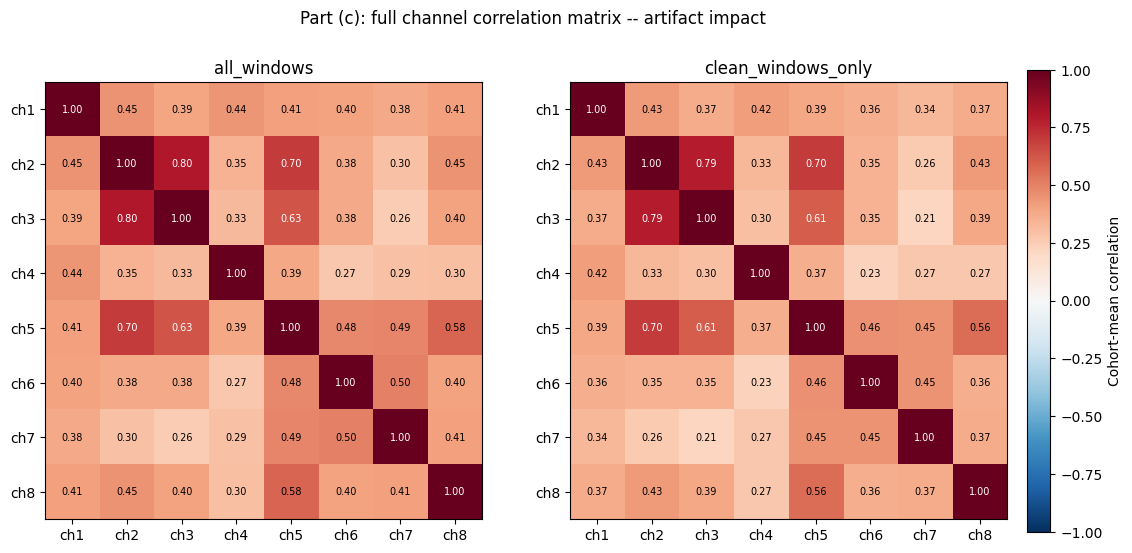

Cohort-mean 8x8 filtered-signal correlation, side by side: all windows (left) vs. artifact-clean windows only (right) -- compare the two to see which channel pairs' correlation was inflated or deflated by artifacts, and check whether ch6 tracks its ear-mates (ch5/ch7/ch8) and mirror ch2 once artifacts are removed.


In [12]:
# Full 8x8 cohort-mean correlation matrix, side by side: all windows vs. clean-only
def mean_matrix(scope):
    d = corr_mat[corr_mat.scope == scope]
    mat = np.eye(8)
    for _, row in d.groupby(["channel_i", "channel_j"])["corr"].mean().reset_index().iterrows():
        i, j = CHANNELS.index(row.channel_i), CHANNELS.index(row.channel_j)
        mat[i, j] = mat[j, i] = row["corr"]
    return mat

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, scope in zip(axes, ["all_windows", "clean_windows_only"]):
    mat = mean_matrix(scope)
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(8)); ax.set_xticklabels(CHANNELS)
    ax.set_yticks(range(8)); ax.set_yticklabels(CHANNELS)
    for i in range(8):
        for j in range(8):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(mat[i, j]) > 0.6 else "black")
    ax.set_title(scope)
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="Cohort-mean correlation")
fig.suptitle("Part (c): full channel correlation matrix -- artifact impact")
plt.show()
print("Cohort-mean 8x8 filtered-signal correlation, side by side: all windows (left) vs. artifact-clean windows only (right) -- compare the two to see which channel pairs' correlation was inflated or deflated by artifacts, and check whether ch6 tracks its ear-mates (ch5/ch7/ch8) and mirror ch2 once artifacts are removed.")


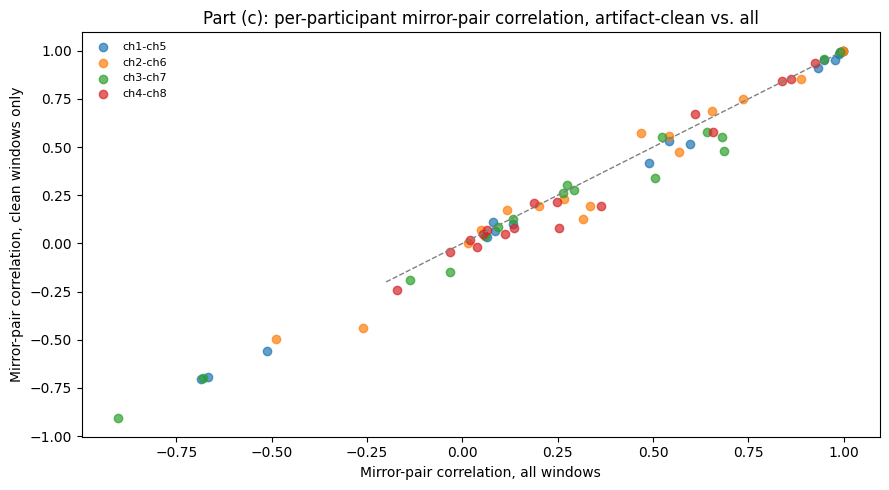

Each dot is one participant's mirror-pair correlation (e.g. ch2-ch6), all-windows value (x) vs. clean-windows value (y) -- points below the diagonal mean artifacts were inflating that participant's apparent left/right symmetry; points above mean artifacts were masking real symmetry.


In [13]:
# Mirror-pair correlation, all vs clean, per participant (shows how much a single participant swings)
mirror = corr_mat[corr_mat.relationship == "mirror"].copy()
mirror["pair"] = mirror.channel_i + "-" + mirror.channel_j
piv = mirror.pivot_table(index=["pid", "pair"], columns="scope", values="corr").reset_index()
fig, ax = plt.subplots(figsize=(9, 5))
for pair, g in piv.groupby("pair"):
    ax.scatter(g["all_windows"], g["clean_windows_only"], label=pair, alpha=0.7)
lims = [-0.2, 1.0]
ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Mirror-pair correlation, all windows")
ax.set_ylabel("Mirror-pair correlation, clean windows only")
ax.set_title("Part (c): per-participant mirror-pair correlation, artifact-clean vs. all")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()
print("Each dot is one participant's mirror-pair correlation (e.g. ch2-ch6), all-windows value (x) vs. clean-windows value (y) -- points below the diagonal mean artifacts were inflating that participant's apparent left/right symmetry; points above mean artifacts were masking real symmetry.")


## Existing pipeline outputs (for reference alongside the above)

In [14]:
snr_report = pd.read_csv(QC.parent / "eeg_channel_snr_report.csv") if (QC.parent / "eeg_channel_snr_report.csv").exists() else pd.read_csv("../data/eeg_channel_snr_report.csv")
quality_report = pd.read_csv(QC / "eeg_channel_quality_report.csv")
quality_report.groupby("channel")["usable_pct"].median().reindex(CHANNELS)


channel
ch1    100.000000
ch2    100.000000
ch3    100.000000
ch4     88.461538
ch5     96.078431
ch6     94.230769
ch7     99.200000
ch8     96.000000
Name: usable_pct, dtype: float64

*Cohort-median `usable_pct` per channel from `eeg_channel_integrity.py`'s hard-fail mask (clip/near-rail/flatline/low-headroom) -- the headline number behind the earlier per-participant plots above.*